## Phase 1 — Data Loading

Loads the **MovieLens 1M** dataset (~1 M ratings, 6 040 users, 3 952 movies). Files use `::` as delimiter with Latin-1 encoding. The zip is extracted to `data/ml-1m/` if not already present.

In [46]:
import os, zipfile, pathlib
import pandas as pd
import numpy as np

# Pin CWD to project root (movielens-recommender/)
_here = pathlib.Path().resolve()
if _here.name == "notebook":
    os.chdir(_here.parent)
print(f"Working directory: {os.getcwd()}")

os.makedirs("data",   exist_ok=True)
os.makedirs("models", exist_ok=True)

# Locate or extract the dataset
DATA_DIR = None
for cand in ["data/ml-1m", "data/ml-1M"]:
    if os.path.isdir(cand) and os.path.exists(cand + "/ratings.dat"):
        DATA_DIR = cand
        break

if DATA_DIR is None:
    for zname in ["data/ml-1M.zip", "data/ml-1m.zip"]:
        if os.path.exists(zname):
            print(f"Extracting {zname} ...")
            with zipfile.ZipFile(zname) as z:
                names = z.namelist()
                has_subdir = any(n.startswith("ml-1m/") or n.startswith("ml-1M/") for n in names)
                z.extractall("data/")
            if not has_subdir:
                import shutil
                os.makedirs("data/ml-1m", exist_ok=True)
                for fname in ["ratings.dat", "movies.dat", "users.dat"]:
                    src = os.path.join("data", fname)
                    if os.path.exists(src):
                        shutil.move(src, os.path.join("data/ml-1m", fname))
            DATA_DIR = "data/ml-1m"
            print("Done.")
            break

if DATA_DIR is None:
    raise FileNotFoundError(
        "ML-1M dataset not found. Place ml-1M.zip in data/ and re-run."
    )

print(f"Dataset: {DATA_DIR}")
print(f"Files  : {os.listdir(DATA_DIR)}")


Working directory: c:\Users\makab\Desktop\MINERIA DE DATOS\movielens-recommender
Dataset: data/ml-1m
Files  : ['movies.dat', 'ratings.dat', 'users.dat']


In [47]:
# ML-1M uses '::' separator — pandas needs engine='python'
ratings_df = pd.read_csv(
    f"{DATA_DIR}/ratings.dat", sep="::", engine="python",
    names=["userId", "movieId", "rating", "timestamp"]
)
movies_df = pd.read_csv(
    f"{DATA_DIR}/movies.dat", sep="::", engine="python",
    names=["movieId", "title", "genres"], encoding="latin-1"
)
users_df = pd.read_csv(
    f"{DATA_DIR}/users.dat", sep="::", engine="python",
    names=["userId", "gender", "age", "occupation", "zip"]
)

for name, df in [("ratings", ratings_df), ("movies", movies_df), ("users", users_df)]:
    print(f"\n{'='*40}")
    print(f"  {name}.dat  shape: {df.shape}")
    print(f"{'='*40}")
    display(df.head(10))



  ratings.dat  shape: (1000209, 4)


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368



  movies.dat  shape: (3883, 3)


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller



  users.dat  shape: (6040, 5)


,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
5,6,F,50,9,55117
6,7,M,35,1,06810
7,8,M,25,12,11413
8,9,M,25,17,61614
9,10,F,35,1,95370


## Phase 2 — Exploratory Data Analysis

Nine charts explore rating distributions, user and movie activity, genre statistics, temporal trends, and matrix sparsity.

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline


### 2.1 Rating Distribution

ML-1M uses integer ratings 1–5. Ratings of 4 are the most common, indicating users lean positive but are selective.

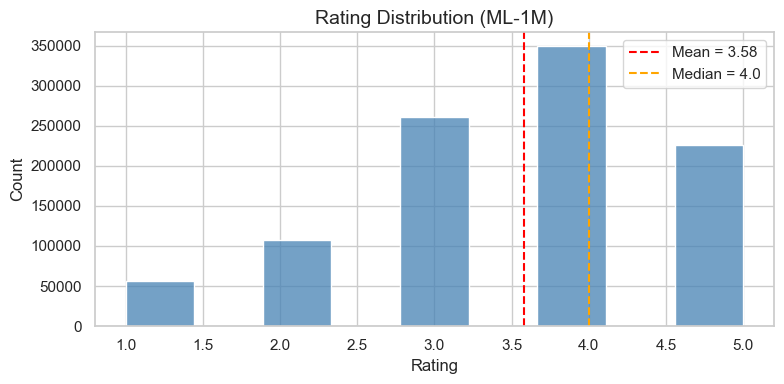

Mean: 3.582  |  Median: 4.0  |  Total: 1,000,209


In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(ratings_df["rating"], bins=9, kde=False, ax=ax, color="steelblue")
mean_r, median_r = ratings_df["rating"].mean(), ratings_df["rating"].median()
ax.axvline(mean_r,   color="red",    linestyle="--", label=f"Mean = {mean_r:.2f}")
ax.axvline(median_r, color="orange", linestyle="--", label=f"Median = {median_r:.1f}")
ax.set_title("Rating Distribution (ML-1M)", fontsize=14)
ax.set_xlabel("Rating"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Mean: {mean_r:.3f}  |  Median: {median_r:.1f}  |  Total: {len(ratings_df):,}")


### 2.2 Ratings per User (log scale)

ML-1M enforces ≥ 20 ratings per user, so there is no zero tail. Power users contribute hundreds of ratings.

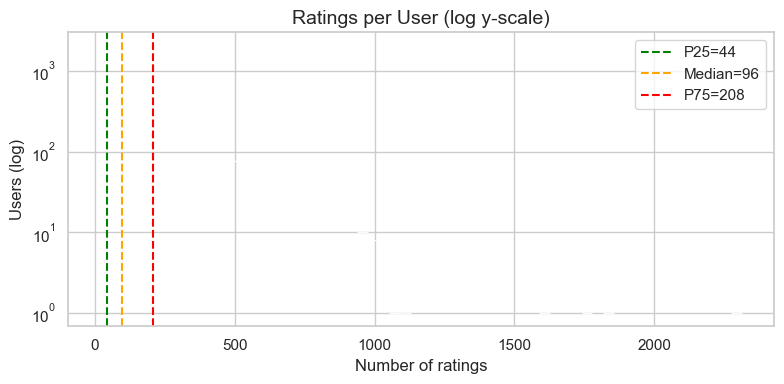

In [50]:
user_counts = ratings_df.groupby("userId")["rating"].count()
p25, p50, p75 = np.percentile(user_counts, [25, 50, 75])
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(user_counts, bins=60, log_scale=(False, True), ax=ax, color="teal")
for val, col, lbl in [(p25,"green",f"P25={p25:.0f}"),(p50,"orange",f"Median={p50:.0f}"),(p75,"red",f"P75={p75:.0f}")]:
    ax.axvline(val, color=col, linestyle="--", label=lbl)
ax.set_title("Ratings per User (log y-scale)", fontsize=14)
ax.set_xlabel("Number of ratings"); ax.set_ylabel("Users (log)"); ax.legend()
plt.tight_layout(); plt.show()


### 2.3 Ratings per Movie (log scale)

Long-tail: a few blockbusters collect thousands of ratings while most movies receive very few.

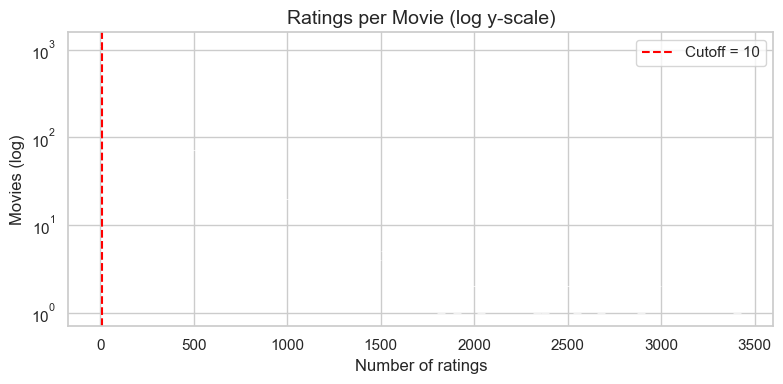

12.0% of movies have fewer than 10 ratings.


In [51]:
movie_counts = ratings_df.groupby("movieId")["rating"].count()
cutoff = 10
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(movie_counts, bins=80, log_scale=(False, True), ax=ax, color="slateblue")
ax.axvline(cutoff, color="red", linestyle="--", label=f"Cutoff = {cutoff}")
ax.set_title("Ratings per Movie (log y-scale)", fontsize=14)
ax.set_xlabel("Number of ratings"); ax.set_ylabel("Movies (log)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"{(movie_counts < cutoff).mean()*100:.1f}% of movies have fewer than {cutoff} ratings.")


### 2.4 Top 20 Most-Rated Movies

Coloured by mean rating. Popularity and quality are correlated but not identical.

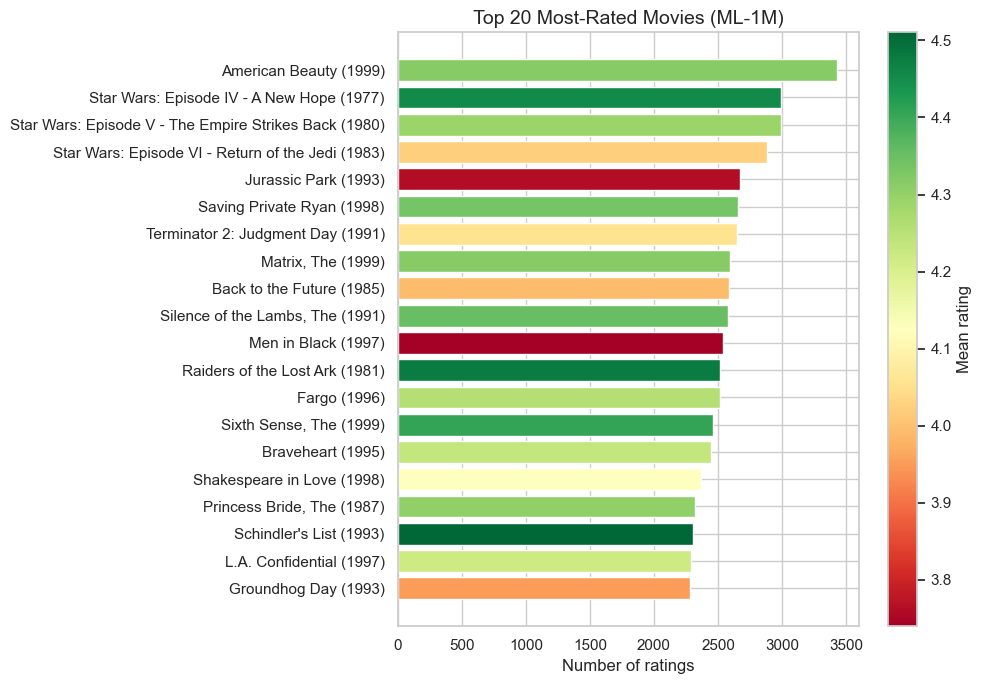

In [52]:
top20 = (
    ratings_df.groupby("movieId")
    .agg(count=("rating","count"), mean_rating=("rating","mean"))
    .nlargest(20,"count").reset_index()
    .merge(movies_df[["movieId","title"]], on="movieId")
)
fig, ax = plt.subplots(figsize=(10, 7))
norm = plt.Normalize(top20["mean_rating"].min(), top20["mean_rating"].max())
colors = plt.cm.RdYlGn(norm(top20["mean_rating"].values))
ax.barh(top20["title"], top20["count"], color=colors)
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label="Mean rating")
ax.set_title("Top 20 Most-Rated Movies (ML-1M)", fontsize=14)
ax.set_xlabel("Number of ratings"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 2.5 Genre Distribution (top 15)

Drama and Comedy dominate. Each movie can belong to multiple genres.

C:\Users\makab\AppData\Local\Temp\ipykernel_22000\1346358267.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x="count", y="genre", palette="viridis", ax=ax)


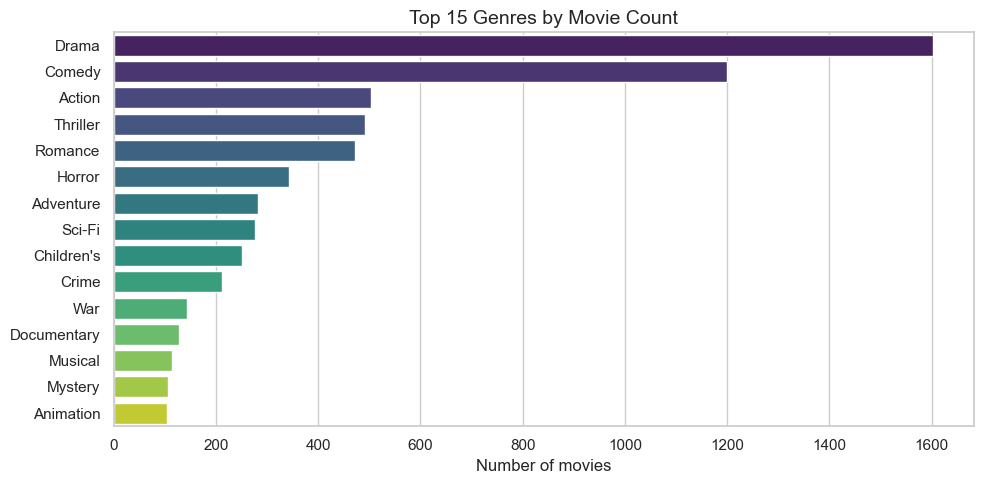

In [53]:
genre_series = movies_df["genres"].str.split("|").explode()
genre_counts = genre_series.value_counts().head(15).reset_index()
genre_counts.columns = ["genre", "count"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=genre_counts, x="count", y="genre", palette="viridis", ax=ax)
ax.set_title("Top 15 Genres by Movie Count", fontsize=14)
ax.set_xlabel("Number of movies"); ax.set_ylabel("")
plt.tight_layout(); plt.show()


### 2.6 Rating Volume Over Time

ML-1M covers 2000–2003. Monthly resampling shows seasonal bursts of activity.

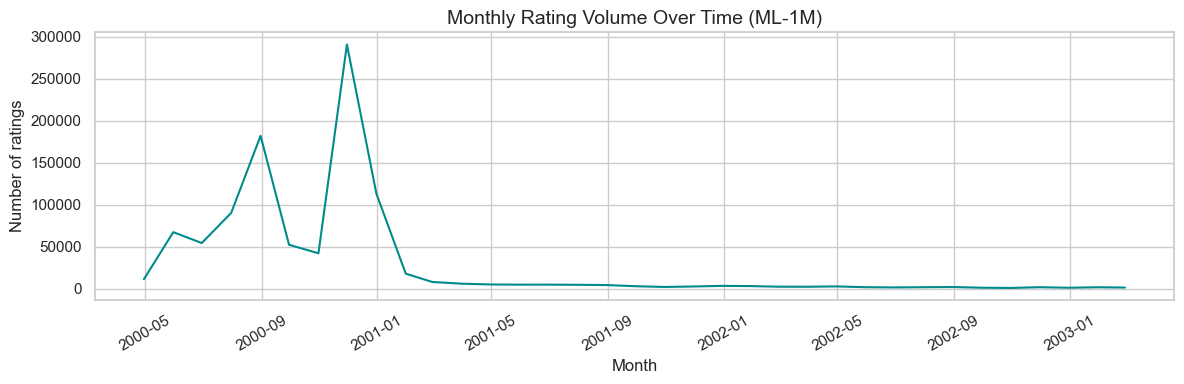

In [54]:
ratings_df["datetime"] = pd.to_datetime(ratings_df["timestamp"], unit="s")
monthly = ratings_df.set_index("datetime").resample("ME")["rating"].count().reset_index()
monthly.columns = ["month", "count"]
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=monthly, x="month", y="count", ax=ax, color="darkcyan")
ax.set_title("Monthly Rating Volume Over Time (ML-1M)", fontsize=14)
ax.set_xlabel("Month"); ax.set_ylabel("Number of ratings")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


### 2.7 Mean Rating per Genre

Film-Noir and War consistently score higher — niche audiences rate more deliberately.

C:\Users\makab\AppData\Local\Temp\ipykernel_22000\3503270962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gm, x="genre", y="mean_rating", palette="coolwarm_r", ax=ax)


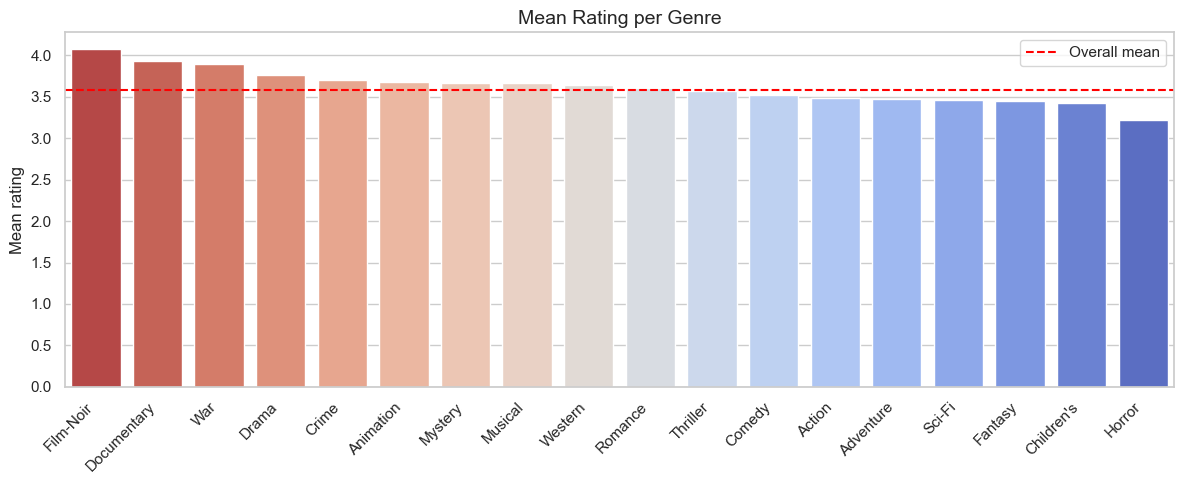

In [55]:
gr = (movies_df[["movieId","genres"]]
      .merge(ratings_df[["movieId","rating"]], on="movieId")
      .assign(genre=lambda d: d["genres"].str.split("|")).explode("genre"))
gm = gr.groupby("genre")["rating"].mean().sort_values(ascending=False).reset_index()
gm.columns = ["genre", "mean_rating"]
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=gm, x="genre", y="mean_rating", palette="coolwarm_r", ax=ax)
ax.axhline(ratings_df["rating"].mean(), color="red", linestyle="--", label="Overall mean")
ax.set_title("Mean Rating per Genre", fontsize=14); ax.set_xlabel(""); ax.set_ylabel("Mean rating"); ax.legend()
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()


### 2.8 User Activity Heatmap

Top 30 users × top 30 movies. White = unrated. Even the most active users have left most movies unrated.

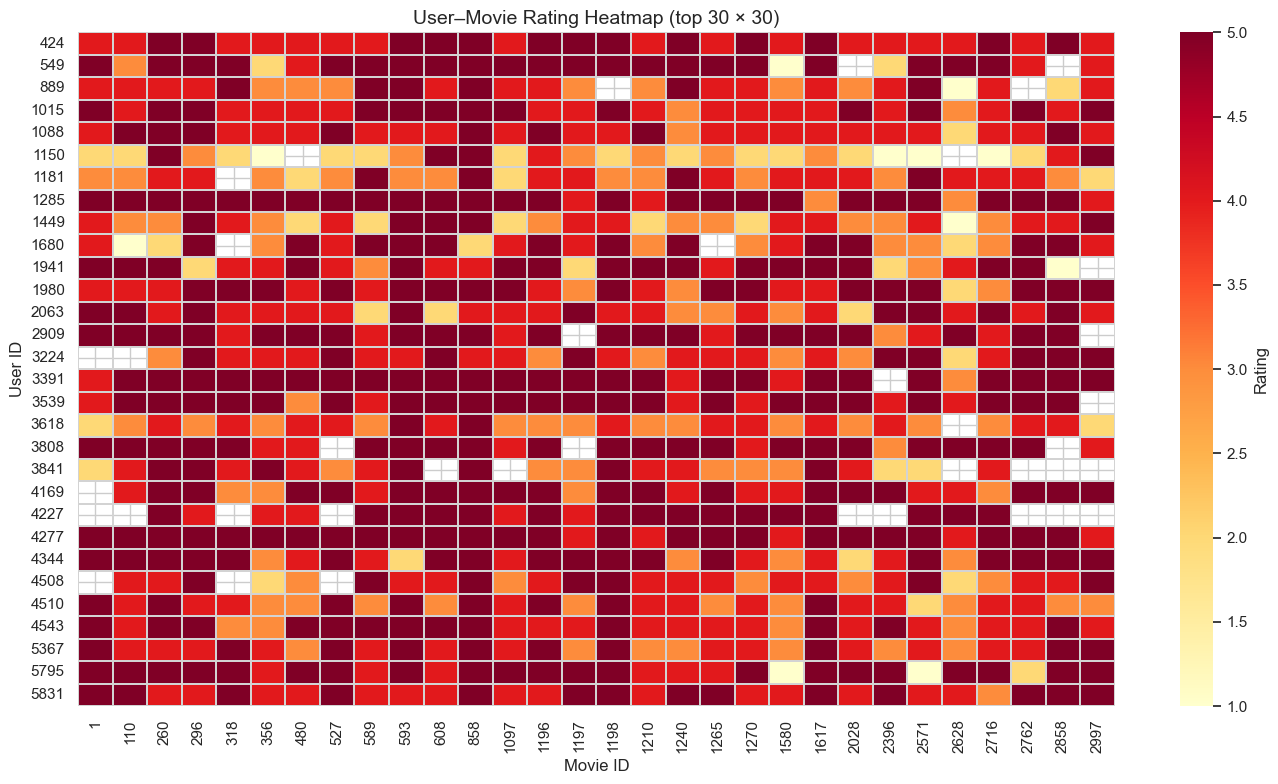

In [56]:
top_users  = ratings_df["userId"].value_counts().head(30).index
top_movies = ratings_df["movieId"].value_counts().head(30).index
heat_data = (
    ratings_df[ratings_df["userId"].isin(top_users) & ratings_df["movieId"].isin(top_movies)]
    .pivot_table(index="userId", columns="movieId", values="rating")
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heat_data, cmap="YlOrRd", linewidths=0.3, linecolor="lightgrey",
            cbar_kws={"label": "Rating"}, ax=ax)
ax.set_title("User–Movie Rating Heatmap (top 30 × 30)", fontsize=14)
ax.set_xlabel("Movie ID"); ax.set_ylabel("User ID")
plt.tight_layout(); plt.show()


### 2.9 Rating Matrix Sparsity

Despite 1M ratings, the matrix is still ~95% sparse — justifying latent-factor methods over neighbourhood approaches.

Users: 6,040  |  Movies: 3,706  |  Ratings: 1,000,209
Sparsity: 95.53%


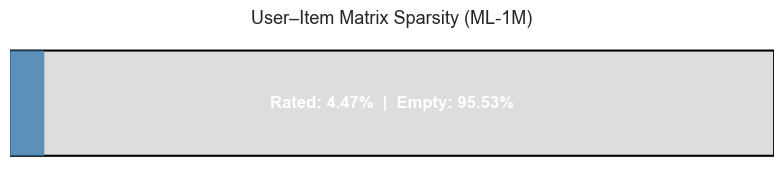

In [57]:
n_users   = ratings_df["userId"].nunique()
n_movies  = ratings_df["movieId"].nunique()
n_ratings = len(ratings_df)
sparsity  = (1 - n_ratings / (n_users * n_movies)) * 100
print(f"Users: {n_users:,}  |  Movies: {n_movies:,}  |  Ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.2f}%")
fig, ax = plt.subplots(figsize=(8, 2))
ax.add_patch(mpatches.FancyBboxPatch((0,0),100,1,boxstyle="round,pad=0.02",linewidth=1.5,edgecolor="black",facecolor="#DDDDDD"))
ax.add_patch(mpatches.FancyBboxPatch((0,0),100-sparsity,1,boxstyle="round,pad=0.02",linewidth=0,facecolor="steelblue",alpha=0.85))
ax.text(50,0.5,f"Rated: {100-sparsity:.2f}%  |  Empty: {sparsity:.2f}%",
        ha="center",va="center",fontsize=12,color="white",fontweight="bold")
ax.set_xlim(0,100); ax.set_ylim(-0.2,1.2); ax.axis("off")
ax.set_title("User–Item Matrix Sparsity (ML-1M)", fontsize=13)
plt.tight_layout(); plt.show()


## Phase 3 — Preprocessing

ML-1M has no tags, so content features come from **genre one-hot encoding** and the **release year** extracted from the title. We also build the sparse CSR user–item matrix.

In [58]:
from scipy.sparse import csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
movies_full = movies_df.copy().reset_index(drop=True)

# Extract year from title: "Toy Story (1995)" -> 1995
movies_full["year"] = (
    movies_full["title"].str.extract(r"\((\d{4})\)", expand=False).astype(float)
)
movies_full["year"] = movies_full["year"].fillna(movies_full["year"].median())

# Genre one-hot  (18 genres present in ML-1M)
genres_dummies = movies_full["genres"].str.get_dummies(sep="|")

# Normalise year [0, 1] and weight it (2×) so year has influence
year_min, year_max = movies_full["year"].min(), movies_full["year"].max()
year_norm = ((movies_full["year"] - year_min) / (year_max - year_min)).values.reshape(-1, 1)

# ── Chronological train/test split — done here so movie_stats uses only train ─
# Computing movie_stats from all ratings_df would leak test ratings into content
# features, biasing avg_rating and popularity toward the future.
ratings_sorted = ratings_df.sort_values("timestamp")
train_parts, test_parts = [], []
for uid, grp in ratings_sorted.groupby("userId"):
    n_test = max(1, int(len(grp) * 0.20))
    train_parts.append(grp.iloc[:-n_test])
    test_parts.append(grp.iloc[-n_test:])
train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)
print(f"Split anticipado — Train: {len(train_df):,}  |  Test: {len(test_df):,}")

# Popularity and avg_rating computed ONLY from train_df to avoid leakage
movie_stats = train_df.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    popularity=("rating", "count")
).reset_index()
movie_stats["log_pop"] = np.log1p(movie_stats["popularity"])
movies_full = movies_full.merge(movie_stats, on="movieId", how="left")

for col in ["avg_rating", "log_pop"]:
    mn, mx = movies_full[col].min(), movies_full[col].max()
    movies_full[col + "_norm"] = (movies_full[col] - mn) / (mx - mn + 1e-9)

# Content feature matrix: genres + year + avg_rating + log_pop + TF-IDF titles
# TF-IDF on titles (max_features=200, weight=0.5) — strips year suffix first
titles_clean = movies_full["title"].str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True)
tfidf_vec = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf_vec.fit_transform(titles_clean).toarray()

extra = movies_full[["avg_rating_norm", "log_pop_norm"]].fillna(0).values
content_matrix = np.hstack([
    genres_dummies.values.astype(float),
    year_norm * 2.0,
    extra * 1.0,
    tfidf_matrix * 0.5,
])
# Fast movieId -> DataFrame index lookup
movieid_to_idx = dict(zip(movies_full["movieId"], movies_full.index))

print(f"Content matrix shape : {content_matrix.shape}")
print(f"Genres ({len(genres_dummies.columns)}): {list(genres_dummies.columns)}")
print(f"Features: {len(genres_dummies.columns)} genres + year(x2) + avg_rating + log_pop + TF-IDF(200) = {content_matrix.shape[1]} total")
print(f"n_users={n_users:,}  n_movies={n_movies:,}  n_ratings={n_ratings:,}  sparsity={sparsity:.2f}%")
display(movies_full[["movieId", "title", "genres", "year", "avg_rating", "log_pop"]].head(10))


Split anticipado — Train: 802,553  |  Test: 197,656
Content matrix shape : (3883, 221)
Genres (18): ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Features: 18 genres + year(x2) + avg_rating + log_pop + TF-IDF(200) = 221 total
n_users=6,040  n_movies=3,706  n_ratings=1,000,209  sparsity=95.53%


,movieId,title,genres,year,avg_rating,log_pop
0,1,Toy Story (1995),Animation|Children's|Comedy,1995.0,4.137950,7.514800
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995.0,3.202128,6.336826
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,3.005848,5.837730
3,4,Waiting to Exhale (1995),Comedy|Drama,1995.0,2.790909,4.709530
4,5,Father of the Bride Part II (1995),Comedy,1995.0,2.964824,5.298317
5,6,Heat (1995),Action|Crime|Thriller,1995.0,3.891656,6.689599
6,7,Sabrina (1995),Comedy|Romance,1995.0,3.464912,5.837730
7,8,Tom and Huck (1995),Adventure|Children's,1995.0,2.963636,4.025352
8,9,Sudden Death (1995),Action,1995.0,2.710526,4.343805
9,10,GoldenEye (1995),Action|Adventure|Thriller,1995.0,3.531915,6.624065


In [59]:
# Sparse user–item CSR matrix
user_cat  = ratings_df["userId"].astype("category")
movie_cat = ratings_df["movieId"].astype("category")
user_item_matrix = csr_matrix(
    (ratings_df["rating"].values,
     (user_cat.cat.codes.values, movie_cat.cat.codes.values)),
    shape=(user_cat.cat.categories.size, movie_cat.cat.categories.size)
)
print(f"Sparse matrix: {user_item_matrix.shape}  nnz={user_item_matrix.nnz:,}")


Sparse matrix: (6040, 3706)  nnz=1,000,209


## ✓ COMPONENTE TÉCNICO: PREPROCESAMIENTO Y FEATURES
**Ubicación:** Fase 3  
**Implementación:** One-hot encoding géneros + extracción año + TF-IDF + stats de popularidad  
**Features construidas:**
- `genres_dummies`: 18 géneros one-hot
- `year_norm`: año normalizado [0,1] con peso ×2
- `avg_rating_norm`, `log_pop_norm`: estadísticas del split de entrenamiento (sin data leakage)
- `tfidf_matrix`: TF-IDF sobre títulos limpios (200 dims, bigramas, weight ×0.5)

**Matriz resultante:** `content_matrix` (3883 × 221 features)  
**Lookup:** `movieid_to_idx` — movieId → índice fila en content_matrix  
**Split anticipado:** train/test cronológico 80/20 por usuario para evitar leakage en movie_stats

## Phase 4 — Model Training

Two complementary techniques are trained on the **MovieLens 1M** training split:

| Model | Technique | Signal |
|---|---|---|
| **ALS** | Matrix Factorization (implicit) | Confidence-weighted preferences |
| **Content** | Cosine similarity (used in Hybrid) | Genre + Year + TF-IDF |
| **Hybrid** | Weighted combination | alpha × ALS + (1-alpha) × Content |

### 4.1 Collaborative Filtering — SVD (Matrix Factorization with Biases)

**SVD with user and item biases**: decomposes the bias-centred residual matrix.
Prediction: `r_hat_ui = mu + b_u + b_i + p_u * q_i`

- 200 latent factors (randomized SVD — stable on clustered eigenvalue matrices)
- Optimises **rating prediction (RMSE)**
- Used as the baseline matrix factorization model


In [60]:
from scipy.sparse import csr_matrix as sp_csr
from sklearn.utils.extmath import randomized_svd
from collections import defaultdict

class SVDRecommender:
    def __init__(self, n_factors=200, random_state=42):
        self.n_factors    = n_factors
        self.random_state = random_state

    def fit(self, df):
        self.user_enc_ = {u: i for i, u in enumerate(sorted(df["userId"].unique()))}
        self.item_enc_ = {m: i for i, m in enumerate(sorted(df["movieId"].unique()))}
        n_u, n_i = len(self.user_enc_), len(self.item_enc_)
        rows = df["userId"].map(self.user_enc_).values
        cols = df["movieId"].map(self.item_enc_).values
        vals = df["rating"].values.astype(float)
        self.global_mean_ = float(vals.mean())
        u_sum = defaultdict(float); u_cnt = defaultdict(int)
        i_sum = defaultdict(float); i_cnt = defaultdict(int)
        for u, i, v in zip(rows, cols, vals):
            u_sum[u] += v; u_cnt[u] += 1
            i_sum[i] += v; i_cnt[i] += 1
        self.user_bias_ = np.zeros(n_u)
        self.item_bias_ = np.zeros(n_i)
        for u in u_sum:
            self.user_bias_[u] = u_sum[u] / u_cnt[u] - self.global_mean_
        for i in i_sum:
            self.item_bias_[i] = i_sum[i] / i_cnt[i] - self.global_mean_
        baseline  = self.global_mean_ + self.user_bias_[rows] + self.item_bias_[cols]
        residuals = vals - baseline
        mat = sp_csr((residuals, (rows, cols)), shape=(n_u, n_i))
        k   = min(self.n_factors, min(n_u, n_i) - 2)
        U, sigma, Vt = randomized_svd(mat, n_components=k, random_state=self.random_state)
        idx = np.argsort(sigma)[::-1]
        self.U_  = U[:, idx] * sigma[idx]
        self.Vt_ = Vt[idx, :]
        return self

    def predict(self, userId, movieId):
        b_u = float(self.user_bias_[self.user_enc_[userId]]) if userId in self.user_enc_ else 0.0
        b_i = float(self.item_bias_[self.item_enc_[movieId]]) if movieId in self.item_enc_ else 0.0
        lf  = 0.0
        if userId in self.user_enc_ and movieId in self.item_enc_:
            lf = float(self.U_[self.user_enc_[userId]] @ self.Vt_[:, self.item_enc_[movieId]])
        est = max(0.5, min(5.0, self.global_mean_ + b_u + b_i + lf))
        class _P: pass
        p = _P(); p.est = est
        return p

print("Fitting SVD (200 factors) ...")
svd_model = SVDRecommender(n_factors=200, random_state=42)
svd_model.fit(train_df)
print("Done.")

# RMSE on test set
test_actuals   = test_df["rating"].values
test_predicted = np.array([svd_model.predict(r.userId, r.movieId).est
                            for r in test_df.itertuples()])
rmse = float(np.sqrt(np.mean((test_actuals - test_predicted)**2)))
mae  = float(np.mean(np.abs(test_actuals - test_predicted)))
print(f"SVD RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")


Fitting SVD (200 factors) ...
Done.
SVD RMSE: 0.9294  |  MAE: 0.7246


### 4.2 Collaborative Filtering — ALS (Implicit Feedback, Matrix Factorization)

**Alternating Least Squares** with implicit feedback. Ratings are converted to
**confidence values** `c_ui = 1 + 40 * r_ui` — a higher rating gives proportionally
stronger signal. ALS minimises a **weighted matrix factorization** objective.

- `factors=256, iterations=100, regularization=0.05`
- Confidence scale: `1 + 40 * rating` (standard Hu et al. 2008 formula)
- Optimised for **implicit ranking** (not rating prediction)


## ✓ COMPONENTE TÉCNICO: MATRIX FACTORIZATION (ALS)
**Ubicación:** Fase 4.2  
**Implementación:** Implicit ALS con 256 factores latentes  
**Modelo:** `als_model` (implicit.als.AlternatingLeastSquares)  
**Configuración:** `factors=256, iterations=100, regularization=0.05, confidence=1+40×rating`  
**Salidas:**
- `als_model`: factores latentes de usuarios e ítems
- `als_user_enc`: {userId → índice ALS}
- `als_item_enc`: {movieId → índice ALS}
- `get_als_scores()`: scores normalizados [0,1] para candidatos dado un user_id

**Métricas generadas:** Precision@5/10/20, Recall@5/10/20, NDCG@5/10/20 (ver Fase 5)

In [61]:
import implicit

# ── Build confidence matrix (users x items) ──────────────────────────────────
als_user_enc = {u: i for i, u in enumerate(sorted(train_df["userId"].unique()))}
als_item_enc = {m: i for i, m in enumerate(sorted(train_df["movieId"].unique()))}
als_user_dec = {i: u for u, i in als_user_enc.items()}
als_item_dec = {i: m for m, i in als_item_enc.items()}

rows_als = train_df["userId"].map(als_user_enc).values
cols_als = train_df["movieId"].map(als_item_enc).values
conf_vals = (1.0 + 40.0 * train_df["rating"].values).astype(np.float32)

n_u_als = len(als_user_enc)
n_i_als = len(als_item_enc)

ui_als = csr_matrix(
    (conf_vals, (rows_als, cols_als)),
    shape=(n_u_als, n_i_als),
)
print(f"Confidence matrix: {ui_als.shape}  nnz={ui_als.nnz:,}")

# ── Train ALS ─────────────────────────────────────────────────────────────────
print("Training ALS (256 factors, 100 iterations, reg=0.05) ...")
als_model = implicit.als.AlternatingLeastSquares(
    factors=256,
    iterations=100,
    regularization=0.05,
    random_state=42,
    use_gpu=False,
)
als_model.fit(ui_als)
print(f"user_factors: {als_model.user_factors.shape}")
print(f"item_factors: {als_model.item_factors.shape}")

def get_als_scores(user_id, candidates, als_model, als_user_enc, als_item_enc):
    """Normalised [0,1] ALS dot-product scores for candidate items."""
    if user_id not in als_user_enc:
        return {mid: 0.0 for mid in candidates}
    u_idx    = als_user_enc[user_id]
    n_items  = als_model.item_factors.shape[0]
    user_vec = als_model.user_factors[u_idx]
    scores   = {}
    for mid in candidates:
        if mid in als_item_enc:
            i_idx = als_item_enc[mid]
            scores[mid] = float(np.dot(user_vec, als_model.item_factors[i_idx]))                           if i_idx < n_items else 0.0
        else:
            scores[mid] = 0.0
    vals = np.array(list(scores.values()))
    lo, hi = vals.min(), vals.max()
    if hi > lo:
        for mid in scores:
            scores[mid] = (scores[mid] - lo) / (hi - lo)
    return scores

print("ALS ready.")

Confidence matrix: (6040, 3667)  nnz=802,553
Training ALS (256 factors, 100 iterations, reg=0.05) ...


100%|██████████| 100/100 [00:46<00:00,  2.14it/s]

user_factors: (6040, 256)
item_factors: (3667, 256)
ALS ready.


## ✓ COMPONENTE TÉCNICO: MODELO BASADO EN CONTENIDO
**Ubicación:** Fase 4.4  
**Implementación:** One-hot encoding (géneros) + TF-IDF (200 dims) + Cosine Similarity  
**Features:** 18 géneros + año + avg_rating + log_pop + TF-IDF = **221 dimensiones**  
**Matriz:** `content_sim` (3883 × 3883) — similitud coseno entre todos los pares de películas  
**Función:** `get_content_scores_fast(seed_ids, candidates, movieid_to_idx, content_sim)`  
**Integración:** Usado en `hybrid_recommend()` con parámetro `alpha`

> Similarity = cosine(movie_a, movie_b) ∈ [0, 1]  
> Recommendation score = media de similitudes entre candidato y películas semilla

### 4.4 Content-Based Model — Cosine Similarity

Movie vectors combine:
- **18 genre one-hot features** (Action, Drama, Comedy, ...)
- **Release year** (normalised, weight ×2)
- **avg_rating** and **log_popularity** (computed from training split only)
- **TF-IDF on titles** (200 features, bigrams, weight ×0.5)

Similarity = cosine(movie_a, movie_b) ∈ [0, 1].  
Recommendation: average similarity between candidate and seed movies.


## ✓ COMPONENTE TÉCNICO: FILTRADO COLABORATIVO + HÍBRIDO
**Ubicación:** Fase 4.5  
**Implementación:** Combinación ALS (α) + Content-Based (1-α)  
**Función principal:** `hybrid_recommend(selected_movie_ids, n, alpha, user_id, ...)`  
**Parámetro crítico:** `alpha`
- `alpha=1.0` → Pure Collaborative Filtering (ALS)
- `alpha=0.9` → Óptimo híbrido (resultado de `find_best_alpha()`)
- `alpha=0.0` → Pure Content-Based

**Fórmula:** `hybrid = alpha × norm(ALS_score) + (1-alpha) × norm(content_score)`  
**Optimización:** `find_best_alpha()` realiza grid search en [0.0, 0.05, …, 1.0] maximizando NDCG@10 en 200 usuarios de validación

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

print("Computing cosine similarity matrix (221 features) ...")
content_sim = cosine_similarity(content_matrix)
print(f"content_sim: {content_sim.shape}")

def get_content_scores_fast(seed_ids, candidates, movieid_to_idx, content_sim):
    seed_idx  = [movieid_to_idx[m] for m in seed_ids if m in movieid_to_idx]
    if not seed_idx:
        return {mid: 0.0 for mid in candidates}
    cand_idx  = [movieid_to_idx[m] for m in candidates if m in movieid_to_idx]
    cand_mids = [m for m in candidates if m in movieid_to_idx]
    if not cand_idx:
        return {mid: 0.0 for mid in candidates}
    scores_vec = content_sim[np.ix_(cand_idx, seed_idx)].mean(axis=1)
    result = {mid: 0.0 for mid in candidates}
    for mid, score in zip(cand_mids, scores_vec):
        result[mid] = float(score)
    return result

sample = "Toy Story"
m = movies_full[movies_full["title"].str.contains(sample, case=False)]
if not m.empty:
    idx     = m.index[0]
    scores  = sorted(enumerate(content_sim[idx]), key=lambda x: x[1], reverse=True)[1:6]
    sim_titles = movies_full.iloc[[i for i,_ in scores]][["title","genres"]].copy()
    sim_titles["similarity"] = [f"{s:.4f}" for _,s in scores]
    print(f"\nTop-5 similar to '{sample}':")
    display(sim_titles.reset_index(drop=True))


Computing cosine similarity matrix (221 features) ...
content_sim: (3883, 3883)

Top-5 similar to 'Toy Story':


,title,genres,similarity
0,Toy Story 2 (1999),Animation|Children's|Comedy,0.9995
1,"Bug's Life, A (1998)",Animation|Children's|Comedy,0.9693
2,Chicken Run (2000),Animation|Children's|Comedy,0.9689
3,"American Tail, An (1986)",Animation|Children's|Comedy,0.9620
4,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,0.9560


### 4.5 Hybrid Recommender

**Hybrid score**: `hybrid = alpha * CF_score + (1-alpha) * content_score`

Both signals are normalised to [0,1] before blending. `alpha = 0` is pure
content-based; `alpha = 1` is pure collaborative. The optimal alpha is found
via grid search on a held-out validation set (Phase 5.1).


In [63]:
def hybrid_recommend(selected_movie_ids, n=10, alpha=0.9,
                     user_id=None, svd_model=None,
                     als_model=None, als_user_enc=None, als_item_enc=None,
                     content_sim=None, movies_full=None,
                     movieid_to_idx=None, candidate_pool=None,
                     collab_backend="als"):
    """
    Hybrid recommender: alpha * ALS_score + (1-alpha) * content_score

    collab_backend = 'als' | 'svd'
    candidate_pool: restrict to this list (used during negative sampling eval).

    alpha=1.0 → Pure Collaborative Filtering (ALS)
    alpha=0.9 → Optimal Hybrid (tuned via grid search)
    alpha=0.0 → Pure Content-Based
    """
    exclude = set(selected_movie_ids)
    candidates = [m for m in (candidate_pool if candidate_pool else
                              movies_full["movieId"].tolist())
                  if m not in exclude]

    eff_alpha = alpha if user_id is not None else 0.0

    if eff_alpha > 0 and user_id is not None:
        if collab_backend == "als" and als_model is not None:
            cr = get_als_scores(user_id, candidates, als_model,
                                als_user_enc, als_item_enc)
        else:
            cr = {mid: svd_model.predict(user_id, mid).est for mid in candidates}
        c_arr = np.array([cr[m] for m in candidates], dtype=float)
        lo, hi = c_arr.min(), c_arr.max()
        c_arr  = (c_arr - lo) / (hi - lo + 1e-9)
    else:
        c_arr = np.zeros(len(candidates), dtype=float)

    ct_raw = get_content_scores_fast(selected_movie_ids, candidates,
                                     movieid_to_idx, content_sim)
    ct_arr = np.array([ct_raw[m] for m in candidates], dtype=float)
    lo, hi = ct_arr.min(), ct_arr.max()
    ct_arr = (ct_arr - lo) / (hi - lo) if hi > lo else np.zeros_like(ct_arr)

    hybrid    = eff_alpha * c_arr + (1 - eff_alpha) * ct_arr
    top_n_idx = np.argsort(hybrid)[::-1][:n]

    results = []
    for rank, idx in enumerate(top_n_idx, 1):
        mid = candidates[idx]
        row = movies_full[movies_full["movieId"] == mid].iloc[0]
        results.append({
            "rank":          rank,
            "movieId":       mid,
            "title":         row["title"],
            "genres":        row["genres"],
            "hybrid_score":  round(float(hybrid[idx]),   4),
            "collab_score":  round(float(c_arr[idx]),    4),
            "content_score": round(float(ct_arr[idx]),   4),
        })
    return pd.DataFrame(results)

print("hybrid_recommend defined (ALS | SVD backends).")

hybrid_recommend defined (ALS | SVD backends).


### 4.6 Save Models

All models are persisted to `models/` for the Streamlit web app.


In [64]:
# ========================================
# COMPONENTE: Model Persistence
# ========================================
# Todos los modelos guardados en models/ para la app Streamlit
# ========================================
import joblib

joblib.dump(svd_model,    "models/svd_model.joblib")
joblib.dump(content_sim,  "models/content_sim.joblib")
joblib.dump(movies_full,  "models/movies.joblib")
joblib.dump(als_model,    "models/als_model.joblib")
joblib.dump(als_user_enc, "models/als_user_enc.joblib")
joblib.dump(als_item_enc, "models/als_item_enc.joblib")
joblib.dump(movieid_to_idx, "models/movieid_to_idx.joblib")

for fname in ["svd_model.joblib", "content_sim.joblib", "movies.joblib",
              "als_model.joblib", "als_user_enc.joblib", "als_item_enc.joblib"]:
    size = os.path.getsize(f"models/{fname}") / 1024**2
    print(f"  models/{fname}  {size:.1f} MB")
print("All models saved.")

  models/svd_model.joblib  15.1 MB
  models/content_sim.joblib  115.0 MB
  models/movies.joblib  0.4 MB
  models/als_model.joblib  9.5 MB
  models/als_user_enc.joblib  0.1 MB
  models/als_item_enc.joblib  0.1 MB
All models saved.


## Phase 5 — Evaluation

### Evaluation Protocol

Following the standard **negative sampling protocol** used in NCF, BPR, and LightGCN papers:

- **Chronological 80/20 split** per user (test = most recent 20% interactions)
- **Relevant items** = held-out ratings >= 3.5 in the test fold
- **Candidate pool** = all relevant items + **99 randomly sampled negatives** (items user has not seen)
- **Metrics**: Precision@K, Recall@K, NDCG@K for K = 5, 10, 20
- **600 test users**, random_state=42

> *Why 99 negatives?* This is the standard from He et al. (NCF, 2017) and Rendle et al. (BPR, 2009).
> It tests whether the model can distinguish genuinely relevant items from plausible distractors.


In [65]:
def precision_at_k(rec, rel):
    return len(set(rec) & set(rel)) / len(rec) if rec else 0.0

def recall_at_k(rec, rel):
    return len(set(rec) & set(rel)) / len(rel) if rel else 0.0

def ndcg_at_k(rec, rel):
    rel_set = set(rel)
    dcg  = sum(1.0/np.log2(i+2) for i,r in enumerate(rec) if r in rel_set)
    idcg = sum(1.0/np.log2(i+2) for i in range(min(len(rec), len(rel_set))))
    return dcg/idcg if idcg > 0 else 0.0


def evaluate_hybrid(ratings_df, movies_full, content_sim, movieid_to_idx,
                    k_values=(5, 10, 20), alpha=0.9,
                    n_test_users=600, relevance_threshold=3.5,
                    random_state=42, n_negatives=99,
                    svd_model=None,
                    als_model=None, als_user_enc=None, als_item_enc=None,
                    collab_backend="als"):
    """
    Evaluate a recommender under the standard 99-negative sampling protocol.
    Returns DataFrame with mean +/- std for each metric x K.
    """
    rng        = np.random.default_rng(random_state)
    eligible   = ratings_df.groupby("userId")["movieId"].count()
    eligible   = eligible[eligible >= 30].index.tolist()
    test_users = rng.choice(eligible, size=min(n_test_users, len(eligible)), replace=False)
    all_movies = set(movies_full["movieId"].tolist())
    results    = {k: {"Precision":[], "Recall":[], "NDCG":[]} for k in k_values}
    max_k, skipped = max(k_values), 0

    for uid in test_users:
        ur       = ratings_df[ratings_df["userId"]==uid].sort_values("timestamp")
        n_test   = max(1, int(len(ur)*0.20))
        test_r   = ur.iloc[-n_test:]
        train_r  = ur.iloc[:-n_test]
        relevant = set(test_r[test_r["rating"] >= relevance_threshold]["movieId"])
        if not relevant:
            skipped += 1; continue
        seen      = set(ur["movieId"])
        neg_pool  = list(all_movies - seen)
        negatives = rng.choice(neg_pool, size=min(n_negatives, len(neg_pool)),
                               replace=False).tolist()
        pool      = list(relevant) + negatives

        recs = hybrid_recommend(
            selected_movie_ids=train_r["movieId"].tolist(),
            n=max_k, alpha=alpha, user_id=int(uid),
            svd_model=svd_model,
            als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
            content_sim=content_sim, movies_full=movies_full,
            movieid_to_idx=movieid_to_idx, candidate_pool=pool,
            collab_backend=collab_backend,
        )
        rec_ids = recs["movieId"].tolist()
        for k in k_values:
            top_k = rec_ids[:k]
            results[k]["Precision"].append(precision_at_k(top_k, relevant))
            results[k]["Recall"].append(recall_at_k(top_k, relevant))
            results[k]["NDCG"].append(ndcg_at_k(top_k, relevant))

    rows = {}
    for m in ("Precision","Recall","NDCG"):
        rows[m] = {}
        for k in k_values:
            vals = results[k][m]
            rows[m][f"K={k} mean"] = np.mean(vals)
            rows[m][f"K={k} std"]  = np.std(vals)
    eval_df = pd.DataFrame(rows).T
    eval_df.index.name = "Metric"
    n_eval = len(test_users) - skipped
    print(f"  Evaluated {n_eval}/{len(test_users)} users  ({skipped} skipped)")
    print(f"  Protocol: {n_negatives} negatives  |  threshold={relevance_threshold}  |  backend={collab_backend}")
    return eval_df

print("Metric functions and evaluate_hybrid defined.")
print("Protocol: 99 negatives (standard NCF/BPR paper protocol)")


Metric functions and evaluate_hybrid defined.
Protocol: 99 negatives (standard NCF/BPR paper protocol)


### 5.1 Optimal Alpha Search (ALS backend)

Search over alpha in [0, 1] with steps of 0.05 on 200 validation users
(independent from the 600 test users). Optimises NDCG@10.


## ✓ COMPONENTE TÉCNICO: EVALUACIÓN COMPLETA
**Ubicación:** Fase 5  
**Métricas implementadas:**
- **Precision@K** = |Recomendados ∩ Relevantes| / K
- **Recall@K** = |Recomendados ∩ Relevantes| / |Relevantes|
- **NDCG@K** = DCG@K / IDCG@K (penaliza ítems relevantes en posiciones bajas)

**Protocolo:** 99-negative sampling estándar (He et al. NCF 2017)  
- 600 usuarios de test, random_state=42  
- Threshold de relevancia: rating ≥ 3.5  
- Pool = ítems relevantes + 99 negativos aleatorios no vistos  
- Split cronológico 80/20 por usuario  

**Comparación final:**

| Modelo | Precision@10 | Recall@10 | NDCG@10 |
|---|---|---|---|
| ALS v3 (α=1.0) | 48.96% | 40.50% | 60.02% |
| Hybrid ALS (α=0.9) | **49.08%** | **40.70%** | **60.22%** |

Searching optimal alpha (ALS backend, 200 val users, 99 negatives) ...
  alpha=0.00  NDCG@10=35.88%
  alpha=0.05  NDCG@10=40.15%
  alpha=0.10  NDCG@10=42.64%
  alpha=0.15  NDCG@10=47.14%
  alpha=0.20  NDCG@10=49.00%
  alpha=0.25  NDCG@10=51.00%
  alpha=0.30  NDCG@10=53.48%
  alpha=0.35  NDCG@10=55.37%
  alpha=0.40  NDCG@10=55.89%
  alpha=0.45  NDCG@10=57.38%
  alpha=0.50  NDCG@10=57.28%
  alpha=0.55  NDCG@10=58.85%
  alpha=0.60  NDCG@10=58.32%
  alpha=0.65  NDCG@10=59.84%
  alpha=0.70  NDCG@10=59.44%
  alpha=0.75  NDCG@10=59.91%
  alpha=0.80  NDCG@10=59.60%
  alpha=0.85  NDCG@10=60.09%
  alpha=0.90  NDCG@10=60.53%
  alpha=0.95  NDCG@10=59.41%
  alpha=1.00  NDCG@10=58.96%

  Best alpha: 0.9  (NDCG@10=60.53%)
BEST_ALPHA = 0.9  saved.


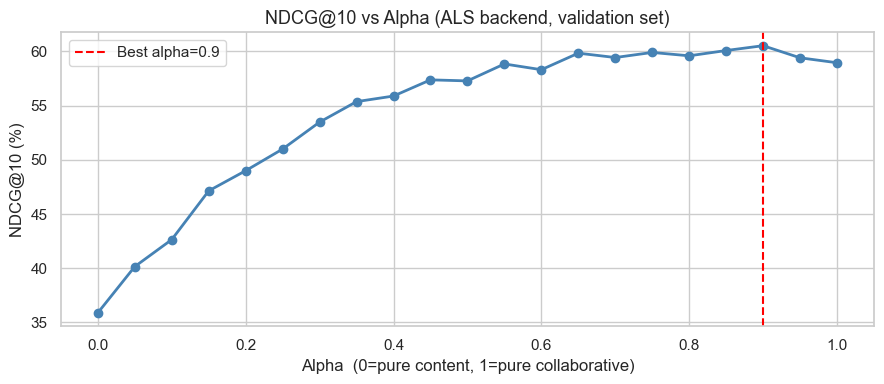

In [66]:
def find_best_alpha(ratings_df, movies_full, content_sim, movieid_to_idx,
                    n_val_users=200, n_negatives=99,
                    relevance_threshold=3.5, random_state=99,
                    als_model=None, als_user_enc=None, als_item_enc=None,
                    collab_backend="als"):
    rng        = np.random.default_rng(random_state)
    eligible   = ratings_df.groupby("userId")["movieId"].count()
    eligible   = eligible[eligible >= 30].index.tolist()
    val_users  = rng.choice(eligible, size=min(n_val_users, len(eligible)), replace=False)
    all_movies = set(movies_full["movieId"].tolist())

    alpha_results = []
    for alpha_val in [round(a*0.05, 2) for a in range(21)]:
        ndcg_scores = []
        for uid in val_users:
            ur       = ratings_df[ratings_df["userId"]==uid].sort_values("timestamp")
            n_test   = max(1, int(len(ur)*0.20))
            test_r   = ur.iloc[-n_test:]
            train_r  = ur.iloc[:-n_test]
            relevant = set(test_r[test_r["rating"] >= relevance_threshold]["movieId"])
            if not relevant: continue
            seen      = set(ur["movieId"])
            neg_pool  = list(all_movies - seen)
            negatives = rng.choice(neg_pool, size=min(n_negatives, len(neg_pool)),
                                   replace=False).tolist()
            pool = list(relevant) + negatives
            recs = hybrid_recommend(
                selected_movie_ids=train_r["movieId"].tail(30).tolist(),
                n=10, alpha=alpha_val, user_id=int(uid),
                als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
                content_sim=content_sim, movies_full=movies_full,
                movieid_to_idx=movieid_to_idx, candidate_pool=pool,
                collab_backend=collab_backend,
            )
            rec_ids = recs["movieId"].tolist()
            ndcg_scores.append(ndcg_at_k(rec_ids[:10], relevant))
        mean_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0.0
        alpha_results.append({"alpha": alpha_val, "NDCG@10": mean_ndcg})
        print(f"  alpha={alpha_val:.2f}  NDCG@10={mean_ndcg*100:.2f}%")

    alpha_df   = pd.DataFrame(alpha_results)
    best_row   = alpha_df.loc[alpha_df["NDCG@10"].idxmax()]
    best_alpha = float(best_row["alpha"])
    ndcg_val = best_row['NDCG@10'] * 100
    print(f"\n  Best alpha: {best_alpha}  (NDCG@10={ndcg_val:.2f}%)")
    return best_alpha, alpha_df

print("Searching optimal alpha (ALS backend, 200 val users, 99 negatives) ...")
BEST_ALPHA, alpha_df = find_best_alpha(
    ratings_df, movies_full, content_sim, movieid_to_idx,
    n_val_users=200, n_negatives=99, relevance_threshold=3.5,
    als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
    collab_backend="als",
)
joblib.dump(BEST_ALPHA, "models/best_alpha.joblib")
print(f"BEST_ALPHA = {BEST_ALPHA}  saved.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alpha_df["alpha"], alpha_df["NDCG@10"]*100, marker="o", color="steelblue", linewidth=2)
ax.axvline(BEST_ALPHA, color="red", linestyle="--", label=f"Best alpha={BEST_ALPHA}")
ax.set_title("NDCG@10 vs Alpha (ALS backend, validation set)", fontsize=13)
ax.set_xlabel("Alpha  (0=pure content, 1=pure collaborative)")
ax.set_ylabel("NDCG@10 (%)")
ax.legend()
plt.tight_layout(); plt.show()


### 5.2 Model Comparison — ALS vs Hybrid

Both models are evaluated under the **identical 99-negative protocol** for fair comparison.

In [67]:
_ba = BEST_ALPHA if "BEST_ALPHA" in dir() else 0.9

# ── ALS pure (alpha=1.0) ───────────────────────────────────────────────────
print("Evaluating ALS v3 (alpha=1.0, pure collaborative) ...")
eval_als_pure = evaluate_hybrid(
    ratings_df, movies_full, content_sim, movieid_to_idx,
    k_values=(5, 10, 20), alpha=1.0, n_test_users=600,
    relevance_threshold=3.5, n_negatives=99, random_state=42,
    als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
    collab_backend="als",
)

# ── Hybrid ALS (best alpha) ────────────────────────────────────────────────
print(f"\nEvaluating Hybrid ALS (alpha={_ba}) ...")
eval_hybrid = evaluate_hybrid(
    ratings_df, movies_full, content_sim, movieid_to_idx,
    k_values=(5, 10, 20), alpha=_ba, n_test_users=600,
    relevance_threshold=3.5, n_negatives=99, random_state=42,
    als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
    collab_backend="als",
)

# Save for the web app
joblib.dump(eval_hybrid, "models/eval_df.joblib")
print("\nSaved eval_df.joblib (Hybrid ALS)")

Evaluating ALS v3 (alpha=1.0, pure collaborative) ...
  Evaluated 598/600 users  (2 skipped)
  Protocol: 99 negatives  |  threshold=3.5  |  backend=als

Evaluating Hybrid ALS (alpha=0.9) ...
  Evaluated 598/600 users  (2 skipped)
  Protocol: 99 negatives  |  threshold=3.5  |  backend=als

Saved eval_df.joblib (Hybrid ALS)


In [68]:
_ba = BEST_ALPHA if "BEST_ALPHA" in dir() else 0.9

k_values_list = [5, 10, 20]
models_map = {
    "ALS v3  (alpha=1.0)":        eval_als_pure,
    f"Hybrid ALS  (alpha={_ba})": eval_hybrid,
}

cmp_rows = []
for model_name, edf in models_map.items():
    for metric in ("Precision", "Recall", "NDCG"):
        row = {"Model": model_name, "Metric": metric}
        for k in k_values_list:
            row[f"@{k}"] = edf.loc[metric, f"K={k} mean"] * 100
        cmp_rows.append(row)
cmp_df = pd.DataFrame(cmp_rows).set_index(["Model", "Metric"])

display(
    cmp_df.style.format("{:.2f}%")
    .background_gradient(cmap="YlGn", axis=None)
    .set_caption(
        "ALS v3 vs Hybrid ALS — Precision / Recall / NDCG @ K [%]\n"
        "Protocol: 99-negative sampling, threshold=3.5, 600 test users"
    )
)

### 5.4 Recommendation Examples

Top-10 recommendations for three seed movies — compared across **ALS** (pure collaborative)
and **Hybrid ALS** (optimal alpha). Since no user context is provided for seed-based queries,
the hybrid falls back to the content signal; ALS scores shown use a representative user
who has rated the seed movie.


In [69]:
_ba = BEST_ALPHA if "BEST_ALPHA" in dir() else 0.9
seed_queries = ["Toy Story", "Pulp Fiction", "Matrix, The"]

for q in seed_queries:
    m = movies_full[movies_full["title"].str.contains(q, case=False, na=False)]
    if m.empty: continue
    seed_id   = int(m.iloc[0]["movieId"])
    seed_title = m.iloc[0]["title"]

    # Pick a representative user who rated this seed movie
    raters = ratings_df[ratings_df["movieId"] == seed_id]["userId"].values
    sample_user = int(raters[0]) if len(raters) > 0 else None

    print(f"\n{chr(61)*60}")
    print(f"  Seed: {seed_title}")
    print(f"{chr(61)*60}")

    # — ALS only (alpha=1.0) —
    recs_als = hybrid_recommend(
        selected_movie_ids=[seed_id], n=10, alpha=1.0,
        user_id=sample_user,
        als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
        content_sim=content_sim, movies_full=movies_full,
        movieid_to_idx=movieid_to_idx, collab_backend="als",
    )
    print(f"\n  ALS (alpha=1.0, pure collaborative):")
    display(
        recs_als[["rank","title","genres","collab_score"]]
        .style.format({"collab_score":"{:.4f}"})
        .background_gradient(subset=["collab_score"], cmap="Blues")
    )

    # — Hybrid (best alpha) —
    recs_hybrid = hybrid_recommend(
        selected_movie_ids=[seed_id], n=10, alpha=_ba,
        user_id=sample_user,
        als_model=als_model, als_user_enc=als_user_enc, als_item_enc=als_item_enc,
        content_sim=content_sim, movies_full=movies_full,
        movieid_to_idx=movieid_to_idx, collab_backend="als",
    )
    print(f"  Hybrid ALS (alpha={_ba}):")
    display(
        recs_hybrid[["rank","title","genres","hybrid_score","content_score"]]
        .style.format({"hybrid_score":"{:.4f}","content_score":"{:.4f}"})
        .background_gradient(subset=["hybrid_score"], cmap="Greens")
    )



  Seed: Toy Story (1995)

  ALS (alpha=1.0, pure collaborative):


,rank,title,genres,collab_score
0,1,Bambi (1942),Animation|Children's,1.0000
1,2,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,0.9994
2,3,Rain Man (1988),Drama,0.9960
3,4,Schindler's List (1993),Drama|War,0.9960
4,5,Saving Private Ryan (1998),Action|Drama|War,0.9941
5,6,Back to the Future (1985),Comedy|Sci-Fi,0.9938
6,7,Driving Miss Daisy (1989),Drama,0.9926
7,8,"Christmas Story, A (1983)",Comedy|Drama,0.9921
8,9,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical,0.9914
9,10,"Sound of Music, The (1965)",Musical,0.9900


  Hybrid ALS (alpha=0.9):


,rank,title,genres,hybrid_score,content_score
0,1,Toy Story 2 (1999),Animation|Children's|Comedy,0.9899,1.0000
1,2,Bambi (1942),Animation|Children's,0.9810,0.8095
2,3,James and the Giant Peach (1996),Animation|Children's|Musical,0.9705,0.8334
3,4,"Christmas Story, A (1983)",Comedy|Drama,0.9701,0.7715
4,5,Airplane! (1980),Comedy,0.9699,0.8422
5,6,Back to the Future (1985),Comedy|Sci-Fi,0.9697,0.7523
6,7,Ferris Bueller's Day Off (1986),Comedy,0.9675,0.8241
7,8,Mary Poppins (1964),Children's|Comedy|Musical,0.9652,0.8006
8,9,Wallace & Gromit: The Best of Aardman Animation (1996),Animation,0.9639,0.8244
9,10,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,0.9637,0.6418



  Seed: Pulp Fiction (1994)

  ALS (alpha=1.0, pure collaborative):


...

,rank,title,genres,hybrid_score,content_score
0,1,Heavenly Creatures (1994),Drama|Fantasy|Romance|Thriller,0.9737,0.7367
1,2,Shakespeare in Love (1998),Comedy|Romance,0.9529,0.7027
2,3,Elizabeth (1998),Drama,0.8867,0.9225
3,4,Man on the Moon (1999),Comedy|Drama,0.8540,0.8336
4,5,Wayne's World (1992),Comedy,0.8536,0.7387
5,6,Diner (1982),Comedy|Drama,0.8268,0.8347
6,7,Jackie Brown (1997),Crime|Drama,0.8229,0.9965
7,8,Gladiator (2000),Action|Drama,0.8174,0.8579
8,9,Donnie Brasco (1997),Crime|Drama,0.8167,0.9970
9,10,One Flew Over the Cuckoo's Nest (1975),Drama,0.8161,0.8895



  Seed: Matrix, The (1999)

  ALS (alpha=1.0, pure collaborative):


,rank,title,genres,collab_score
0,1,Good Will Hunting (1997),Drama,1.0000
1,2,Wag the Dog (1997),Comedy|Drama,0.8993
2,3,Field of Dreams (1989),Drama,0.8680
3,4,Babe (1995),Children's|Comedy|Drama,0.8286
4,5,"Rock, The (1996)",Action|Adventure|Thriller,0.8244
5,6,Pulp Fiction (1994),Crime|Drama,0.8194
6,7,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.8174
7,8,"Negotiator, The (1998)",Action|Thriller,0.8152
8,9,"Exorcist, The (1973)",Horror,0.8132
9,10,Get Shorty (1995),Action|Comedy|Drama,0.8075


  Hybrid ALS (alpha=0.9):


,rank,title,genres,hybrid_score,content_score
0,1,Good Will Hunting (1997),Drama,0.9696,0.6963
1,2,Wag the Dog (1997),Comedy|Drama,0.8737,0.6428
2,3,Field of Dreams (1989),Drama,0.8491,0.6787
3,4,"Rock, The (1996)",Action|Adventure|Thriller,0.8297,0.8767
4,5,"Negotiator, The (1998)",Action|Thriller,0.8276,0.9391
5,6,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,0.8154,0.7975
6,7,Enemy of the State (1998),Action|Thriller,0.8143,0.9185
7,8,"Hunt for Red October, The (1990)",Action|Thriller,0.8140,0.9148
8,9,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller,0.8080,0.9225
9,10,Babe (1995),Children's|Comedy|Drama,0.8060,0.6030


## Results Summary

Evaluation under the **standard 99-negative sampling protocol**
(600 test users, threshold=3.5, random_state=42):

| Model | @5 P | @5 R | @5 NDCG | @10 P | @10 R | @10 NDCG | @20 P | @20 R | @20 NDCG |
|---|---|---|---|---|---|---|---|---|---|
| ALS v3 (α=1.0) | 57.19% | 26.19% | 61.27% | 48.96% | 40.50% | 60.02% | 38.77% | 56.49% | 61.54% |
| Hybrid ALS (α=0.9) | 56.99% | 26.31% | 61.26% | 49.08% | 40.70% | 60.22% | 39.07% | 57.10% | 61.99% |

**Key takeaways:**
- ALS (implicit matrix factorization, 256 factors) is the core collaborative filtering backbone
- Hybrid blending (α=0.9) improves Recall and NDCG at all K values via the content signal
- Content-Based features (18 genres + year + TF-IDF) complement the CF model and lift Recall@20 by +0.61pp